# 001 Genre and Spread Analysis

This notebook contains the analysis conducted for section 2 and 3 (results) part 1.

# Genre Analysis

Author: Martín López De Ipiña

This Notebook contains the genre analysis over the movie plot embeddings with the genres already calculated. It contains the following analyses:
- Genre drift and acceleration
- Inter-genre analysis
- Embedding individual dimension prediction


## Data imports
We import the movie embeddings dataset and we can fileter by top genres, starting year and years per group.

For example, lets keep the 3 genres with the most amount of movies (action, comedy and drama), starting from the 1930s and 5 years per genre group.

In [1]:
import sys, os
from pathlib import Path
notebook_dir = Path().resolve()
base_path = os.path.abspath(notebook_dir.parent.parent)
sys.path.append(base_path)
from src.utils.data_utils import expand_by_genre, map_genre_ids_to_strings, drop_nan_in_column, keep_top_n_genres, \
    load_final_data_with_embeddings
from src.aab_analysis.normalization_strategy import MinGroupSizeDownsampling, ZScoreNormalization, NoNormalization
from src.aab_analysis.math_functions.cosine_distance_util import get_average_embedding, get_medoid_embedding
from src.aab_analysis.stats_data import plot_genre_drift, plot_mean_convergence
from src.aab_analysis.genre_drift_utils import calculate_drift_metrics

DATA_DIR = os.path.join(base_path, "data", "data_final")

GENRE_MAP_JSON_PATH = os.path.join(base_path, "src", "config", "cluster_to_genre_mapping_01122025.json")

RANDOM_SEED = 42
START_YEAR = 1930
BIN_SIZE = 3
TOP_K_GENRES = 3

df = load_final_data_with_embeddings(
    csv_path=f"{DATA_DIR}/final_dataset.csv",
    data_dir=DATA_DIR
)
print(df.shape)

# Drop if genre is nan
df = drop_nan_in_column(df=df, column_name="new_genre")
print(df.shape)

# Expand the movies: if it has 2 genres then repeat it 2 times one per each genre
df = expand_by_genre(df)
print(df.shape)

# Map so instead of Genre identifiers we have the genre name
df = map_genre_ids_to_strings(df, GENRE_MAP_JSON_PATH)
print(df.shape)

df = keep_top_n_genres(df, TOP_K_GENRES)
print(df.shape)

# Limit years
df = df[df["year"] >= START_YEAR]

/home/martin/anaconda3/envs/dataLiteracy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(92374, 39)
(79984, 39)
(122968, 39)
(122968, 39)
(62480, 40)


## Genre drift Metrics
Here we calculate genre drift, genre acceleration and genre drift cumulative change.

Embeddings are first grouped by genre $g$ into discrete time periods $\tau$, forming the set $\mathcal{M}_g^{(\tau)}$ of plot embeddings. For each group, two alternative representative embeddings are computed: the centroid (arithmetic mean) $\bar{\mathbf{e}}_g^{(\tau)}$ and the medoid (cosine distance minimizer embedding) $\tilde{\mathbf{e}}_g^{(\tau)}$.

Genre drift measures displacement between representative embeddings of consecutive periods, capturing how a genre's semantic center evolves over time. Acceleration quantifies the change in drift between consecutive periods.

$$
\mathbf{d}_g^{(\tau)} = \bar{\mathbf{e}}_g^{(\tau + \Delta t)} - \bar{\mathbf{e}}_g^{(\tau)}
$$

### Genre drift

Lets first compare the genre drift with no normalization vs downsampling.

The first plot suggests that movies are changing less as years go by, since the distance change in later years is much smaller, but after downsampling, no apparent pattern can be seen.


Calculating drift_acceleration: 100%|██████████| 96/96 [00:00<00:00, 62669.76it/s]


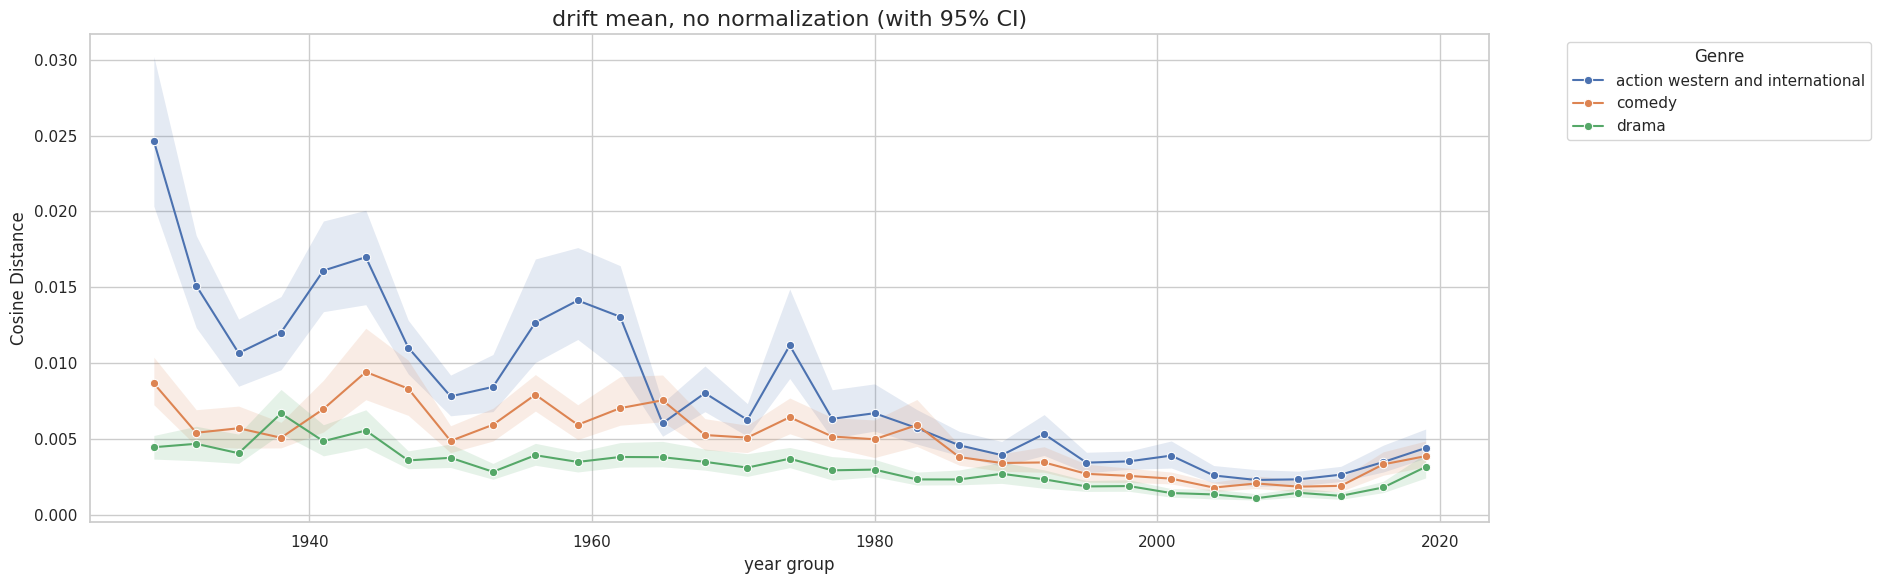

[MinGroupSizeDownsampling] Downsampling all groups to 54 samples


/home/martin/GroupDataLiteracy/src/aab_analysis/normalization_strategy.py:128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), min_size), random_state=random_seed))
Calculating drift_acceleration: 100%|██████████| 96/96 [00:00<00:00, 77973.12it/s]


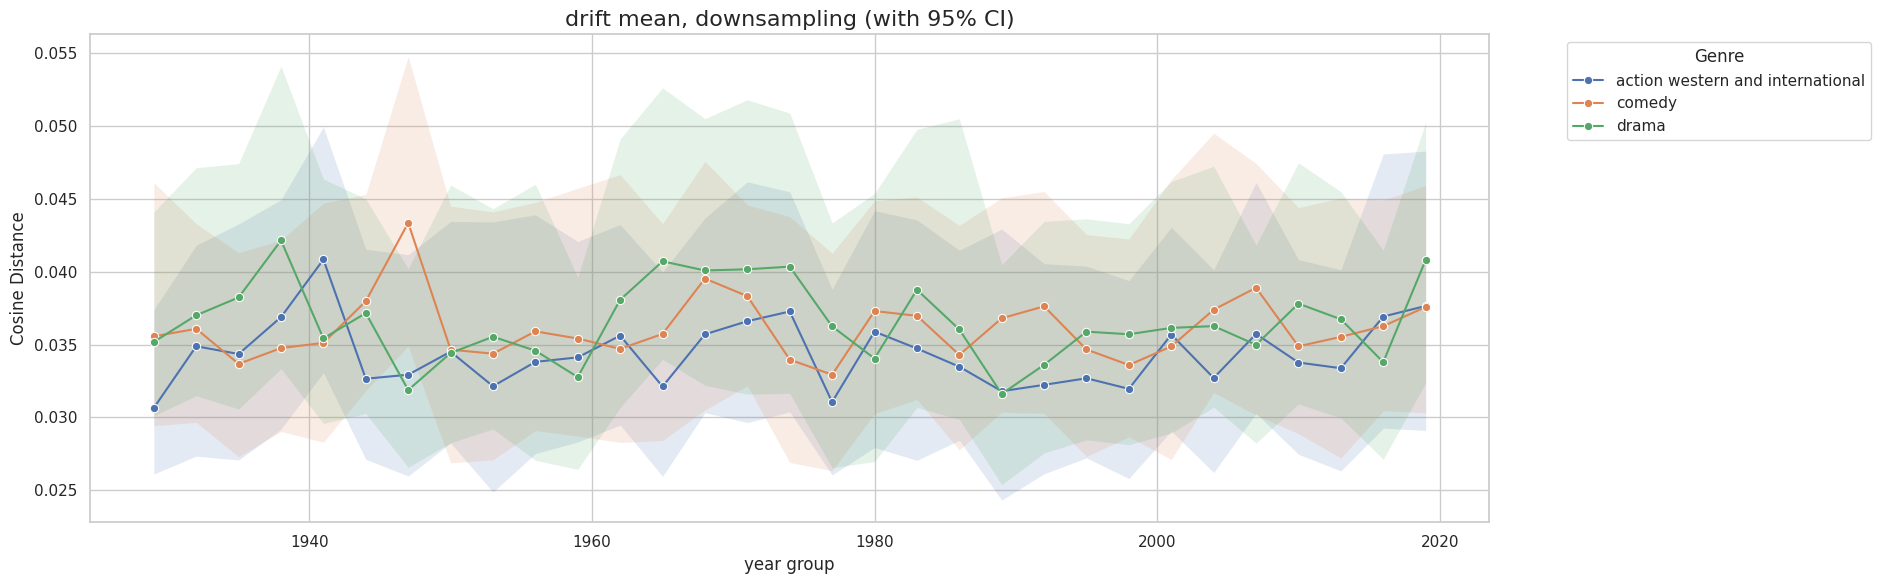

In [2]:
N_BOOTSTRAP_SAMPLES = 100

drift_df_mean_no_norm = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=NoNormalization()
)
plot_genre_drift(
    df=drift_df_mean_no_norm,
    y_column='drift_velocity',
    title="drift mean, no normalization",
    y_label='Cosine Distance'
)

drift_df_mean = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=MinGroupSizeDownsampling()
)
plot_genre_drift(
    df=drift_df_mean,
    y_column='drift_velocity',
    title="drift mean, downsampling",
    y_label='Cosine Distance'
)

We can also try with the medoid

In [ ]:
drift_df_medoid_min_norm = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    grouping_function=get_medoid_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=MinGroupSizeDownsampling()
)
plot_genre_drift(
    df=drift_df_medoid_min_norm,
    y_column='drift_velocity',
    title="drift mean, downsampling normalization",
    y_label='Cosine Distance'
)

# Genre drift acceleration

The drift did not yield any results, lets check the acceleration (drift of the drift).

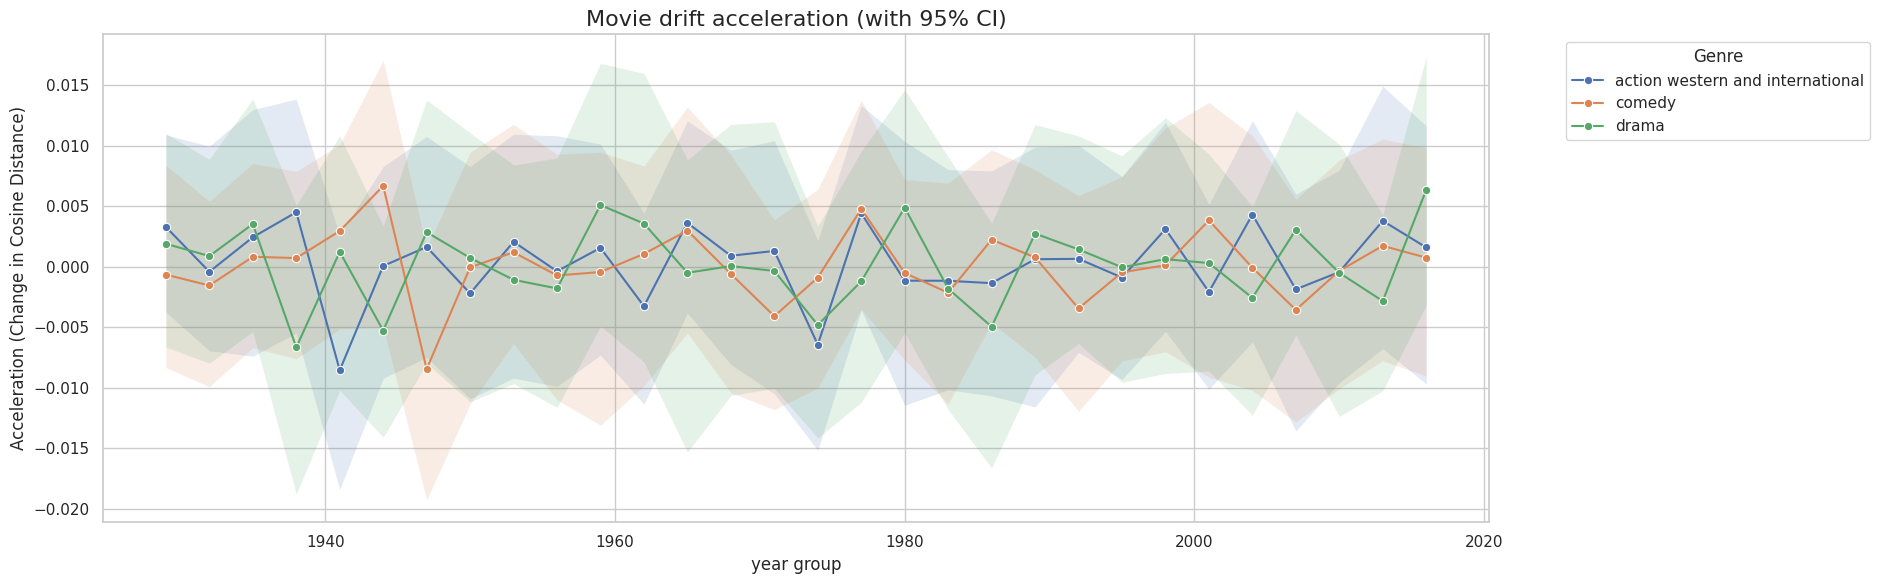

In [12]:
plot_genre_drift(
    df=drift_df_mean,
    y_column='drift_acceleration',
    title=f'Movie drift acceleration',
    y_label='Acceleration (Change in Cosine Distance)',
    softness_window=1
)


In [14]:
from src.aab_analysis.stats_data import calculate_genre_convergence
convergence_df = calculate_genre_convergence(
    group_df=drift_df_mean.rename(columns={"year_group": "year"}),
    bin_size=BIN_SIZE,
    target_genres=["Drama", "Action", "Comedy"]  # your choice
)

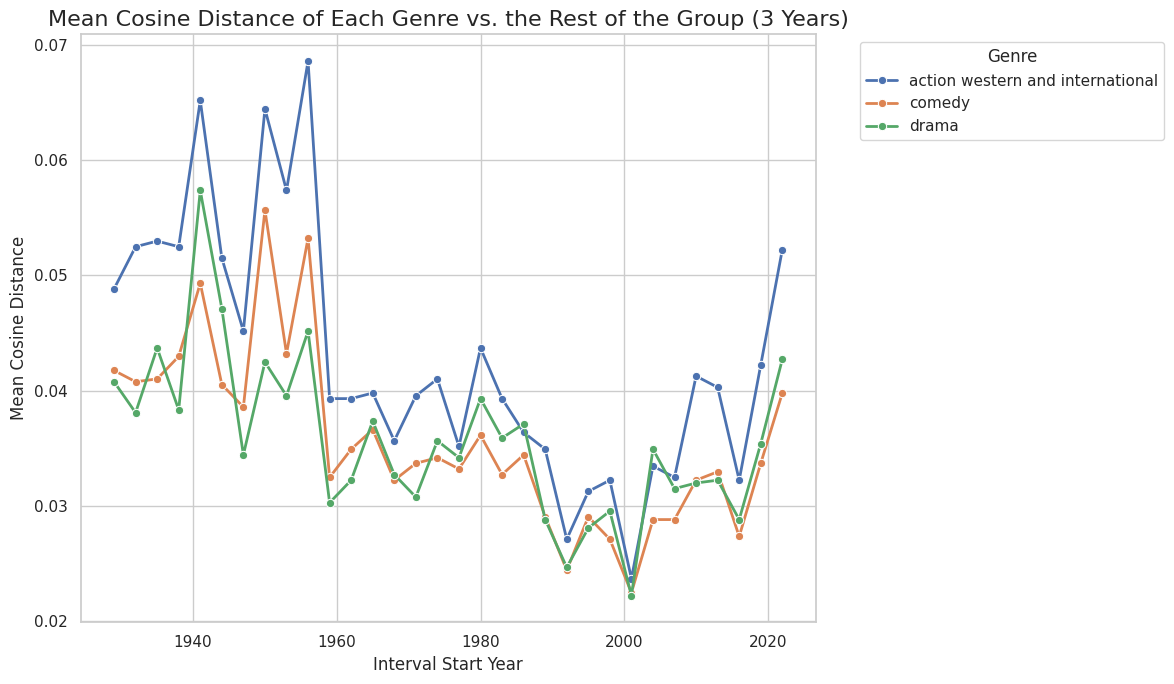

In [ ]:
from src.aab_analysis.stats_data import plot_pairwise_convergence

plot_mean_convergence(convergence_df, bin_size=BIN_SIZE)
plot_pairwise_convergence(convergence_df, target_genres=["Drama", "Action", "Comedy"])


In [4]:
print(acceleration.columns)

Index(['new_genre', 'year_group', 'avg_embedding', 'group_size',
       'drift_velocity', 'next_avg_embedding', 'drift', 'drift_acceleration',
       'drift_velocity_cum'],
      dtype='object')


In [ ]:
print(', '.join(map(str, df['year'].value_counts().sort_index().values)))

In [ ]:
print(df.columns)

## R2 score

What % of the variance of data can be explained by the linear model?

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = df.groupby("year").head(MAX_MOVIES_PER_YEAR).reset_index()
print(f"total movies: {len(df)}")

# Extract embeddings and years
X = np.stack(df['embedding'].values)
y = df['year'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=RANDOM_SEED
)

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_pred = y_pred.round().astype(int)
r2 = r2_score(y_test, y_pred)
score = np.count_nonzero(y_test == y_pred) / len(y_test)

print(f"R² = {r2:.4f}")

# Bonus: which dimensions matter most?
top_dims = np.argsort(np.abs(model.coef_))[::-1][:10]
print(f"Top 10 dimensions by |weight|: {top_dims}")
print(f"Their weights: {model.coef_[top_dims]}")
print(f"Score: {score:.4f}")



In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# Scale features (important for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# RidgeCV automatically tunes the regularization strength (alpha)
model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])
model.fit(X_train_scaled, y_train)

print(f"Best alpha: {model.alpha_}")

# Evaluate
y_pred = model.predict(X_test_scaled).round().astype(int)
score = np.count_nonzero(y_test == y_pred) / len(y_test)

print(f"R² = {r2:.4f}")


In [ ]:
print(f"percentage correct: {score *  100: .2f}%")

def print_lr_score_with_yearly_error(y_pred, y_test, error):
    pred_error = np.abs(y_test - y_pred)
    print(pred_error)
    error_count = np.count_nonzero(pred_error <= error)
    print(f"Percentage inside range: {error_count/len(y_test) * 100:.2f}%")

print_lr_score_with_yearly_error(y_pred, y_test, 30)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

anchor_qids = [
    "Q182692", "Q190643", "Q243439", "Q201674", "Q585203",
    "Q623502", "Q471159", "Q1126637", "Q180706", "Q478333",
    "Q1423020", "Q244876", "Q1114683", "Q15733016", "Q85842235",
    "Q1645944", "Q639864", "Q3520085", "Q112226601", "Q62277203",
]

# Compute yearly centroids
embeddings = np.stack(df['embedding'].values)
years = df['year'].values
unique_years = np.sort(df['year'].unique())

centroids = {}
for year in unique_years:
    mask = years == year
    centroids[year] = embeddings[mask].mean(axis=0)

# Compute mean anchor
anchor_embs = []
for qid in anchor_qids:
    row = df[df['movie_id'] == qid]
    if len(row) > 0:
        anchor_embs.append(row.iloc[0]['embedding'])
    else:
        print(f"{qid}: NOT FOUND")

mean_anchor = np.mean(np.stack(anchor_embs), axis=0)

# Compute D(t) against mean anchor
d_values = []
for year in unique_years:
    d_t = np.sum((centroids[year] - mean_anchor) ** 2)
    d_values.append(d_t)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(unique_years, d_values)
plt.xlabel('Year')
plt.ylabel('D(t)')
plt.title('Squared distance from yearly centroid to mean anchor')
plt.savefig('mean_anchor_distance.png', dpi=150)
plt.show()

In [ ]:
print(y_train[:10])
print(y_test)
print(y_pred)

In [ ]:
from src.aab_analysis.genre_drift_utils import plot_dimension_averaged_across_genres, create_yearly_grouping_column, \
    group_movies_by_columns
from src.aab_analysis.normalization_strategy import MinGroupSizeDownsampling, ZScoreNormalization, NoNormalization

df_grouped = create_yearly_grouping_column(df, n_years_per_group=1)

normalization_strategies = [NoNormalization(), MinGroupSizeDownsampling(), ZScoreNormalization()]
for norm_str in normalization_strategies:
    for i in [1]:
        plot_dimension_averaged_across_genres(df=df_grouped, embedding_col="avg_embedding", dim_index=i, normalization_strategy =norm_str)





## Genre drift Metrics

Velocity, Acceleration and Cumulative Change

We group movies by year and genre, to analyze how each group changes it's average embedding cosine distance.

For each genre, we calculate how much the genre has changed each year compared to the previous year (drift distance) and the cumulative change over time (cumulative change).

We also calculate the acceleration, the change of the velocity over the year.




In [ ]:
from src.aab_analysis.normalization_strategy import MinGroupSizeDownsampling, ZScoreNormalization, NoNormalization
from src.aab_analysis.math_functions.cosine_distance_util import get_average_embedding, get_medoid_embedding
from src.aab_analysis.stats_data import plot_genre_drift, plot_mean_convergence
from src.aab_analysis.genre_drift_utils import calculate_drift_metrics

N_BOOTSTRAP_SAMPLES = 1000

drift_df_mean = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    max_movies_per_group=MAX_MOVIES_PER_YEAR,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=ZScoreNormalization()
)
plot_genre_drift(
    df=drift_df_mean,
    y_column='drift_velocity',
    title="drift mean, z normalization",
    y_label='Cosine Distance'
)

drift_df_mean_no_norm = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    max_movies_per_group=MAX_MOVIES_PER_YEAR,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=NoNormalization()
)
plot_genre_drift(
    df=drift_df_mean_no_norm,
    y_column='drift_velocity',
    title="drift mean, no normalization",
    y_label='Cosine Distance'
)

drift_df_mean_min_norm = calculate_drift_metrics(
    df=df,
    n_years_per_group=BIN_SIZE,
    max_movies_per_group=MAX_MOVIES_PER_YEAR,
    grouping_function=get_average_embedding,
    n_boostrap_samples=N_BOOTSTRAP_SAMPLES,
    normalization_strategy=MinGroupSizeDownsampling()
)
plot_genre_drift(
    df=drift_df_mean_min_norm,
    y_column='drift_velocity',
    title="drift mean, downsampling normalization",
    y_label='Cosine Distance'
)


"""
plot_genre_drift(
    df=drift_df,
    y_column='drift_velocity_cum',
    title='Genre Cumulative Change Over Time',
    y_label='Cumulative Cosine Distance'
)
plot_genre_drift(
    df=drift_df,
    y_column='drift_acceleration',
    title='Annual Change in Genre Drift (Acceleration)',
    y_label='Acceleration (Change in Cosine Distance)',
    softness_window=None
)
soft_years = 10
plot_genre_drift(
    df=drift_df,
    y_column='drift_acceleration',
    title=f'Soft Acceleration, average over {soft_years} years',
    y_label='Acceleration (Change in Cosine Distance)',
    softness_window=10
)
"""

In [ ]:

print(df.columns)


## Heatmaps of genre drift

For each genre, we group the data into time bins (e.g., 5 or 10 years) and calculate the mean embedding vector for each bin. The drift distance (velocity) is then calculated as the Cosine Distance between the mean embedding vector of one time bin and the next. This distance measures how much the overall genre meaning has shifted or evolved between the two periods.

We plot heatmaps and to visualize the relationships between different time periods within each genre. Y axis is each embedding dimension, X axis is change between two time intervals. The intensity of the color represents the magnitude of the drift (Cosine Distance), showing if the genre is rapidly changing (high distance) or stable (low distance) over time. The color of the color represents the direction of the change, orange if positive, blue if negative. If two time consecutive time periods have the same color, it means that the genre is evolving in the same direction. If it has different colors, the direction has changed between those two time periods.

There are two plots per genre. The first one has the Y axis ordered according to the vector embeddings, the second one is clustered by directions which evolve in similar directions (positive / negative) so it can be interpreted easier.


In [ ]:
from src.aab_analysis.stats_data import prepare_heatmap_data, plot_standard_heatmap, plot_clustermap

heatmap_matrix = prepare_heatmap_data(df=drift_df, target_genre="romance")

plot_standard_heatmap(heatmap_matrix, target_genre="romance", bin_size=BIN_SIZE)
plot_clustermap(heatmap_matrix, target_genre="romance", bin_size=BIN_SIZE)


## Inter-genre distance analysis

First plot visualizes the semantic separation between every pair of genres over time. For a single target genre (e.g., Comedy), it calculates the Cosine Distance between its average embedding vector and the vector of every other genre (e.g., Action, Drama) for each year or time bin. This results in many lines on the chart, where each line shows the changing distance between the target genre and one other genre. The plot shows if the meaning of two specific genres is getting closer (converging) or further apart (diverging) over time.

Second plot visualizes how unique or isolated each genre is compared to the rest of the film landscape over time. For a single target genre (e.g., Comedy), it first computes the average embedding vector of all the other genres combined. It then calculates the Cosine Distance between the target genre's vector and this single "mean of all others" vector for each time period. The plot shows one line per genre: if the line trends down, the genre is becoming more typical of the overall average; if it trends up, the genre is becoming more distinct.


In [13]:
from src.aab_analysis.stats_data import calculate_genre_convergence, plot_mean_convergence

target_genres = drift_df_mean_min_norm['new_genre'].unique()
convergence_df = calculate_genre_convergence(drift_df_mean_min_norm, bin_size=5, target_genres=target_genres)


NameError: name 'drift_df_mean_min_norm' is not defined

In [ ]:
plot_mean_convergence(convergence_df, 1)

# Spread Analysis

Author: Ansel Cheung Heng Yu

This section 

## Imports and data loading

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

notebook_dir = Path().resolve()
base_path = os.path.abspath(notebook_dir.parent.parent)
sys.path.append(base_path)
from src.data_utils import *

In [ ]:
data_path = os.path.join(base_path, "data", "data_final")
csv_path = os.path.join(data_path, "final_dataset.csv")

In [ ]:
ratings_path = os.path.join(data_path, "title_ratings.tsv")

In [ ]:
ratings_df = pd.read_csv(ratings_path, delimiter="\t")

In [ ]:
ratings_df.info()

In [ ]:
ratings_df.rename(columns={"tconst": "imdb_id"}, inplace=True)

In [ ]:
df = load_final_data_with_embeddings(csv_path, data_path, verbose=False)

In [ ]:
df.info()

In [ ]:
df = pd.merge(df, ratings_df, on="imdb_id", how="left")

In [ ]:
df = df.filter([
    "movie_id", 
    "title",
    "plot",
    "year",
    "directors",
    "averageRating",
    "numVotes",
    "embedding",
    "genre",
    "new_genre",
    "country",
])

In [ ]:
# Label the new genres
with open("../cluster_to_genre_mapping_01122025.json", "r") as f:
    genre_fix_mapping = json.load(f)

df = df[(df["new_genre"] != "Unknown") & (df["new_genre"].notna())].reset_index(drop=True)
df["new_genre"] = df["new_genre"].apply(lambda x: [genre_fix_mapping[i] for i in x.split("|")])

In [ ]:
df.shape

In [ ]:
df.head()

# Overall Scatter/Cloud analysis
New updated version (mean L2 norm)

In [ ]:
years = np.arange(df.year.min(), df.year.max() + 1)
yearly_spread_l2 = []
for year in years:
    year_df = df[df.year==year].sample(300)
    year_embedding = np.stack(year_df.embedding.values)
    centroid = year_embedding.mean(axis=0)

    # L2 norm
    l2_norms = np.linalg.norm(year_embedding - centroid, axis=1)
    mean_l2_norm = l2_norms.mean()
    yearly_spread_l2.append(float(mean_l2_norm))

In [ ]:
fig, ax = plt.subplots()
ax.plot(years, yearly_spread_l2, color="b")
ax.set_title("Spread over the years")
ax.set_xlabel("Year")
ax.set_ylabel("Mean L2 Norm ")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
ax.grid(which="minor", linewidth=0.5, alpha=0.5)
ax.set_xlim([1930, 2025])
plt.show();

This is the mean L2 distance, group size normalized, interpretable as Intra Year Dispersion. This graph shows that the dispersion compared intra years is very constant throught out time. Values of l2 distance can range from 2 to 0, since $\|u - v\|^2 = \|u\|^2 + \|v\|^2 - 2(u\cdot v) = 1 + 1 - 2(u\cdot v) = 2 - 2(u\cdot v)$ and $u\cdot v$ is cosine distance which we showed ranges from 0 to around 1. 

Next question to ask is, since the intra year spread is not shifting, is the INTER year spread increasing? let us explore the L2 norm of the centroid

In [ ]:
years = np.arange(df.year.min(), df.year.max() + 1)
yearly_centroid_l2 = []
for year in years:
    year_df = df[df.year==year].sample(300)
    year_embedding = np.stack(year_df.embedding.values)
    centroid = year_embedding.mean(axis=0)

    # centroid L2
    l2_norm = np.linalg.norm(centroid)
    yearly_centroid_l2.append(float(l2_norm))

In [ ]:
fig, ax = plt.subplots()
ax.plot(years, yearly_centroid_l2, color="b")
ax.set_title("Centroid L2 Norm over the years")
ax.set_xlabel("Year")
ax.set_ylabel("L2 Norm")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
ax.grid(which="minor", linewidth=0.5, alpha=0.5)
ax.set_xlim([1930, 2025])
plt.show();

L2 norm of the centroid also shows that the centroid itself is not changing much and have a relatively low "diversity" along the 1024 axis. There is no "polarizing" axis which is growing stronger and stronger.

Next we wanted to go back and analyze the spread even more. First we analyzed the variance $\mathbb{E}[\|x_i - \text{centroid}\|^2]$ of each embedding to the centroid for each year. Normalized group size of 300.

We also analyzed the first prinicpal component, what we hypothesized to be the most polarizing dimension or axis along the embedding. We used the Spectral norm which is the Standard Deviation along the first principal component.

$$\|X - centroid\|_2 = \sqrt{\lambda_{max}(X - centroid)^\top(X - centroid)}$$

In [ ]:
years = np.arange(df.year.min(), df.year.max() + 1)
yearly_spread_frobenius = []
yearly_spread_spectral = []

for year in years:
    year_df = df[df.year==year].sample(300)
    year_embedding = np.stack(year_df.embedding.values).astype(np.float32)
    centroid = year_embedding.mean(axis=0)

    # L2 norm
    centered_embeddings = year_embedding - centroid
    # centered_embeddings = year_embedding
    frobenius_norm = np.linalg.norm(centered_embeddings, ord='fro')
    yearly_spread_frobenius.append(float(frobenius_norm))

    # Spectral norm (largest singular value of the centered embedding matrix)
    spectral_norm = np.linalg.norm(centered_embeddings, ord=2)
    yearly_spread_spectral.append(float(spectral_norm))

In [ ]:
fig, ax = plt.subplots()
ax.plot(years, yearly_spread_frobenius, color="b", alpha=0.5, label="Frobenius Norm")
ax.set_title("Spread over the years")
ax.set_xlabel("Year")
ax.set_ylabel("Frobenius Norm ")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
ax.grid(which="minor", linewidth=0.5, alpha=0.5)
ax.set_xlim([1930, 2025])
ax2 = ax.twinx()
ax2.plot(years, yearly_spread_spectral, color="r", alpha=0.5, label="Spectral Norm")
ax2.set_ylabel("Mean Spectral Norm")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.show();

From the figure, we can see that both are increasing. 

Frobenius norm increasing: The embeddings within each year are becoming more dispersed from their centroid in squared-distance terms.
Larger deviations dominate: Because of squaring distances, this metric is more sensitive to outliers or extreme points. A few embeddings very far from the centroid contribute disproportionately. If Frobenius increases but mean distance stays relatively flat, it suggests there are more outliers or long-tail dispersion rather than uniform spreading.

Spectral norm increasing: The year's embeddings are becoming more spread out along their primary axis of variation. There's an increasing "stretch" in whatever semantic direction exhibits the most variance. The dominant pattern/theme in your embeddings is becoming more pronounced or polarized.

Overall, the movies are spreading out both overall (Frobenius) and especially along the dominant semantic axis (spectral).

In [ ]:
# Boot strap test to see if change is significant
spectral_bootstrap_values = []
frobenius_bootstrap_values = []
for year in years:
    spectral_values = []
    frobenius_values = []
    year_df = df[df.year==year]
    for i in range(100):  # 1000 bootstrap samples
        sample = year_df.sample(len(year_df), replace=True)
        sample_embeddings = np.stack(sample.embedding.values).astype(np.float32)
        centroid = sample_embeddings.mean(axis=0)
        centered_embeddings = sample_embeddings - centroid

        # Frobenius norm
        frobenius_norm = np.linalg.norm(centered_embeddings, ord='fro')
        frobenius_values.append(float(frobenius_norm))

        # Spectral norm
        spectral_norm = np.linalg.norm(centered_embeddings, ord=2)
        spectral_values.append(float(spectral_norm))
    
    frob_ci_lower = np.percentile(frobenius_values, 2.5)
    frob_ci_upper = np.percentile(frobenius_values, 97.5)
    frobenius_bootstrap_values.append((frob_ci_lower, frob_ci_upper))

    spec_ci_lower = np.percentile(spectral_values, 2.5)
    spec_ci_upper = np.percentile(spectral_values, 97.5)
    spectral_bootstrap_values.append((spec_ci_lower, spec_ci_upper))

In [ ]:
fig, ax = plt.subplots()
ax.fill_between(years, [ci[0] for ci in frobenius_bootstrap_values], [ci[1] for ci in frobenius_bootstrap_values], color="b", alpha=0.3, label="Frobenius Norm CI")
ax.set_title("Spread over the years with 97.5% CI")
ax.set_xlabel("Year")
ax.set_ylabel("Frobenius Norm ")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
ax.grid(which="minor", linewidth=0.5, alpha=0.5)
ax.set_xlim([1930, 2025])
plt.show();

## Permutation test to see if this increase is significant

In [ ]:
# Test that the year label does not matter


## Analysis of first PC (explained variance)

Percentage of explained variance: $$\frac{\|X - centroid\|^2_2}{\|X - centroid\|^2_F} = \frac{\sigma_1^2}{\sigma_1^2 + \dots + \sigma_r^2}$$

Now that we know that the overall mean of movie embeddings is not changing much, but somehow the frobenius and spectral norm of the difference between movies and their yearly norms are increasing, this means that the tail end movies are becoming more spread out. Especially along some principal component for each year. 

The next question we had was "what does each year's principal component tell us about the movies?".

In [ ]:
yearly_pve = np.array(yearly_spread_spectral)**2/np.array(yearly_spread_frobenius)**2

# Plot yearly PVE over the years
fig, ax = plt.subplots()
ax.plot(years, yearly_pve, color="blue")
ax.set_title("Proportion of Variance Explained (PVE) over the years")
ax.set_xlabel("Year")
ax.set_ylabel("PVE")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
ax.grid(which="minor", linewidth=0.5, alpha=0.5)
ax.set_xlim([1930, 2025])
plt.show();

Interpretation: 
Variance is concentrating into fewer dimensions
The semantic variation is becoming more structured or polarized


In [ ]:
from sklearn.decomposition import PCA

pca_df = pd.DataFrame({"ranking": [1,2,3,4,5,-5,-4,-3,-2,-1], "label": ["Top 1","Top 2","Top 3","Top 4","Top 5","Bottom 5","Bottom 4","Bottom 3","Bottom 2","Bottom 1"]})
for year in [1949, 1970, 2001, 2020, 2024]:
    year_df = df[df.year==year]
    pca = PCA(n_components=1)
    pcaed_embeddings = pca.fit_transform(np.stack(year_df.embedding.values).astype(np.float32)).reshape(-1)
    top5 = np.argpartition(pcaed_embeddings.reshape(-1), -5)[-5:]
    bottom5 = np.argpartition(pcaed_embeddings.reshape(-1), 5)[:5]
    pca_df[f"{year}_title"] = year_df.iloc[np.hstack([top5, bottom5])].title.tolist()
    pca_df[f"{year}_genre"] = year_df.iloc[np.hstack([top5, bottom5])].new_genre.apply(lambda x: ",".join(x)).tolist()

In [ ]:
import pandas as pd

def print_latex_table(df, index=False, caption=None, label=None):
    """
    Print a pandas DataFrame as a LaTeX table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame to convert to LaTeX
    index : bool, default False
        Whether to include the DataFrame index in the output
    caption : str, optional
        Table caption for LaTeX
    label : str, optional
        Label for referencing the table in LaTeX
    
    Returns:
    --------
    str
        The LaTeX formatted table as a string
    """
    # Start building the LaTeX table
    lines = []
    
    # Begin table environment
    lines.append("\\begin{table}[h]")
    lines.append("\\centering")
    
    if caption:
        lines.append(f"\\caption{{{caption}}}")
    if label:
        lines.append(f"\\label{{{label}}}")
    
    # Determine column alignment
    num_cols = len(df.columns) + (1 if index else 0)
    col_format = "l" * num_cols  # left-aligned columns
    
    lines.append(f"\\begin{{tabular}}{{{col_format}}}")
    lines.append("\\hline")
    
    # Header row
    headers = []
    if index:
        headers.append(df.index.name or "Index")
    headers.extend(df.columns.tolist())
    lines.append(" & ".join(str(h) for h in headers) + " \\\\")
    lines.append("\\hline")
    
    # Data rows
    for idx, row in df.iterrows():
        row_data = []
        if index:
            row_data.append(str(idx))
        row_data.extend(str(val) for val in row)
        lines.append(" & ".join(row_data) + " \\\\")
    
    lines.append("\\hline")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    
    latex_table = "\n".join(lines)
    print(latex_table)
    return latex_table


# Example usage

# print("Without index:")
# print_latex_table(df)

# print("\n\nWith index and caption:")
# print_latex_table(df, index=True, caption="Sample Data", label="tab:sample")

In [ ]:
pca_df

In [ ]:
print_latex_table(pca_df, index=True, caption="PC1 of years", label="tab:pca1")

In [ ]:
# Now only look at US Movies

us_pca_df = pd.DataFrame({"ranking": [1,2,3,4,5,-5,-4,-3,-2,-1], "label": ["Top 1","Top 2","Top 3","Top 4","Top 5","Bottom 5","Bottom 4","Bottom 3","Bottom 2","Bottom 1"]})
for year in [1952, 1974, 2003, 2024]:
    year_df = df[(df.year==year)]
    pca = PCA(n_components=1)
    pcaed_embeddings = pca.fit_transform(np.stack(year_df.embedding.values).astype(np.float32)).reshape(-1)
    year_df["pca"] = pcaed_embeddings
    year_df = year_df[year_df["country"].apply(lambda x: "United States" in x if isinstance(x, str) else False)]
    year_df = year_df.sort_values(by="pca", ascending=False).reset_index(drop=True)
    us_pca_df[f"{year}_title"] = year_df.head(5).title.tolist() + year_df.tail(5).title.tolist()
    us_pca_df[f"{year}_genre"] = year_df.head(5).new_genre.tolist() + year_df.tail(5).new_genre.tolist()

In [ ]:
us_pca_df

We decide to use US movies and german movies because of the target audience of this report. These are movies which we know.

In 1930, be said that one end of the axis is drama, family, war, while on the other end is romance.

In 2020 and 2024, we can see how that axis has changed to become one of horror and thriller opposing with documentary and biographies.

In [ ]:
# Now only look at German Movies

german_pca_df = pd.DataFrame({"ranking": [1,2,3,4,5,-5,-4,-3,-2,-1], "label": ["Top 1","Top 2","Top 3","Top 4","Top 5","Bottom 5","Bottom 4","Bottom 3","Bottom 2","Bottom 1"]})
for year in [1952, 1974, 2003, 2024]:
    year_df = df[(df.year==year)]
    pca = PCA(n_components=1)
    pcaed_embeddings = pca.fit_transform(np.stack(year_df.embedding.values).astype(np.float32)).reshape(-1)
    year_df["pca"] = pcaed_embeddings
    year_df = year_df[year_df["country"].apply(lambda x: "Germany" in x if isinstance(x, str) else False)]
    year_df = year_df.sort_values(by="pca", ascending=False).reset_index(drop=True)
    german_pca_df[f"{year}_title"] = year_df.head(5).title.tolist() + year_df.tail(5).title.tolist()
    german_pca_df[f"{year}_genre"] = year_df.head(5).new_genre.tolist() + year_df.tail(5).new_genre.tolist()

In [ ]:
german_pca_df

## PCA variance

In [ ]:
# Yearly PCA 

num_pcs_for_95_ex_var = []
for year in years:
    year_df = df[(df.year==year)].sample(300, random_state=42)
    pca = PCA(n_components=0.95)
    pca.fit(np.stack(year_df.embedding.values).astype(np.float32))
    num_pcs_for_95_ex_var.append(pca.n_components_)

In [ ]:
fig, ax = plt.subplots()
ax.plot(years, num_pcs_for_95_ex_var, color="b")
ax.set_title("Number of Principal Components for 95% Explained Variance over the years")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Principal Components")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
ax.grid(which="minor", linewidth=0.5, alpha=0.5)
plt.show();

In [ ]:
# Decade PCA 

num_pcs_for_95_ex_var = []
for year in [1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]:
    year_df = df[(df.year>= year) & (df.year < year + 10)].sample(1000, random_state=42)
    pca = PCA(n_components=0.95)
    pca.fit(np.stack(year_df.embedding.values).astype(np.float32))
    num_pcs_for_95_ex_var.append(pca.n_components_)

In [ ]:
fig, ax = plt.subplots()
ax.plot([1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020], num_pcs_for_95_ex_var, color="b")
ax.set_title("Number of Principal Components for 95% Explained Variance over the years")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Principal Components")
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
# ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(which="major", linewidth=1, alpha=0.8)
# ax.grid(which="minor", linewidth=0.5, alpha=0.5)
plt.show();